<a href="https://colab.research.google.com/github/sriramrangu/Machine-Learning-Practice/blob/main/K_MeansHandsOn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Problem Statement:
We have dataset containing some statics of cricket players
Our goal is to group the players with the similar perfomance characterics into clusters.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
# from sklearn.metrics import

In [3]:
data = pd.read_csv("/content/Cricket.csv", encoding='latin')
data.head()

,Player,Span,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0
0,SR Tendulkar (INDIA),1989-2012,463,452,41,18426,200*,44.83,21367,86.23,49,96,20
1,KC Sangakkara (Asia/ICC/SL),2000-2015,404,380,41,14234,169,41.98,18048,78.86,25,93,15
2,RT Ponting (AUS/ICC),1995-2012,375,365,39,13704,164,42.03,17046,80.39,30,82,20
3,ST Jayasuriya (Asia/SL),1989-2011,445,433,18,13430,189,32.36,14725,91.20,28,68,34
4,DPMD Jayawardene (Asia/SL),1998-2015,448,418,39,12650,144,33.37,16020,78.96,19,77,28


In [ ]:
# Read the data and understand (rows and columns)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79 entries, 0 to 78
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Player  79 non-null     object 
 1   Span    79 non-null     object 
 2   Mat     79 non-null     int64  
 3   Inns    79 non-null     int64  
 4   NO      79 non-null     int64  
 5   Runs    79 non-null     int64  
 6   HS      79 non-null     object 
 7   Ave     79 non-null     float64
 8   BF      79 non-null     int64  
 9   SR      79 non-null     float64
 10  100     79 non-null     int64  
 11  50      79 non-null     int64  
 12  0       79 non-null     int64  
dtypes: float64(2), int64(8), object(3)
memory usage: 8.2+ KB


In [ ]:
# as span col is not used directly we will convert into exp col

In [5]:
data[["debut","retired"]] = data['Span'].str.split('-',n=1, expand=True)

In [6]:
data.head()

,Player,Span,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0,debut,retired
0,SR Tendulkar (INDIA),1989-2012,463,452,41,18426,200*,44.83,21367,86.23,49,96,20,1989,2012
1,KC Sangakkara (Asia/ICC/SL),2000-2015,404,380,41,14234,169,41.98,18048,78.86,25,93,15,2000,2015
2,RT Ponting (AUS/ICC),1995-2012,375,365,39,13704,164,42.03,17046,80.39,30,82,20,1995,2012
3,ST Jayasuriya (Asia/SL),1989-2011,445,433,18,13430,189,32.36,14725,91.20,28,68,34,1989,2011
4,DPMD Jayawardene (Asia/SL),1998-2015,448,418,39,12650,144,33.37,16020,78.96,19,77,28,1998,2015


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79 entries, 0 to 78
Data columns (total 15 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Player   79 non-null     object 
 1   Span     79 non-null     object 
 2   Mat      79 non-null     int64  
 3   Inns     79 non-null     int64  
 4   NO       79 non-null     int64  
 5   Runs     79 non-null     int64  
 6   HS       79 non-null     object 
 7   Ave      79 non-null     float64
 8   BF       79 non-null     int64  
 9   SR       79 non-null     float64
 10  100      79 non-null     int64  
 11  50       79 non-null     int64  
 12  0        79 non-null     int64  
 13  debut    79 non-null     object 
 14  retired  79 non-null     object 
dtypes: float64(2), int64(8), object(5)
memory usage: 9.4+ KB


In [ ]:
# convert debut and retired into int columns

In [8]:
data['debut'] = data['debut'].astype(int)
data['retired'] = data['retired'].astype(int)

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79 entries, 0 to 78
Data columns (total 15 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Player   79 non-null     object 
 1   Span     79 non-null     object 
 2   Mat      79 non-null     int64  
 3   Inns     79 non-null     int64  
 4   NO       79 non-null     int64  
 5   Runs     79 non-null     int64  
 6   HS       79 non-null     object 
 7   Ave      79 non-null     float64
 8   BF       79 non-null     int64  
 9   SR       79 non-null     float64
 10  100      79 non-null     int64  
 11  50       79 non-null     int64  
 12  0        79 non-null     int64  
 13  debut    79 non-null     int64  
 14  retired  79 non-null     int64  
dtypes: float64(2), int64(10), object(3)
memory usage: 9.4+ KB


In [10]:
data["Exp"] = data['retired'] - data['debut']

In [11]:
data

,Player,Span,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0,debut,retired,Exp
0,SR Tendulkar (INDIA),1989-2012,463,452,41,18426,200*,44.83,21367,86.23,49,96,20,1989,2012,23
1,KC Sangakkara (Asia/ICC/SL),2000-2015,404,380,41,14234,169,41.98,18048,78.86,25,93,15,2000,2015,15
2,RT Ponting (AUS/ICC),1995-2012,375,365,39,13704,164,42.03,17046,80.39,30,82,20,1995,2012,17
3,ST Jayasuriya (Asia/SL),1989-2011,445,433,18,13430,189,32.36,14725,91.20,28,68,34,1989,2011,22
4,DPMD Jayawardene (Asia/SL),1998-2015,448,418,39,12650,144,33.37,16020,78.96,19,77,28,1998,2015,17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74,CG Greenidge (WI),1975-1991,128,127,13,5134,133*,45.03,7908,64.92,11,31,3,1975,1991,16
75,Misbah-ul-Haq (PAK),2002-2015,162,149,31,5122,96*,43.40,6945,73.75,0,42,6,2002,2015,13
76,PD Collingwood (ENG),2001-2011,197,181,37,5092,120*,35.36,6614,76.98,5,26,7,2001,2011,10
77,A Symonds (AUS),1998-2009,198,161,33,5088,156,39.75,5504,92.44,6,30,15,1998,2009,11


In [15]:
data = data.drop(columns=['Span', 'debut', 'retired'])

In [17]:
data['HS'] = data['HS'].str.replace("*","")

In [18]:
data['HS'] = data['HS'].astype(int)

In [19]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79 entries, 0 to 78
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Player  79 non-null     object 
 1   Mat     79 non-null     int64  
 2   Inns    79 non-null     int64  
 3   NO      79 non-null     int64  
 4   Runs    79 non-null     int64  
 5   HS      79 non-null     int64  
 6   Ave     79 non-null     float64
 7   BF      79 non-null     int64  
 8   SR      79 non-null     float64
 9   100     79 non-null     int64  
 10  50      79 non-null     int64  
 11  0       79 non-null     int64  
 12  Exp     79 non-null     int64  
dtypes: float64(2), int64(10), object(1)
memory usage: 8.2+ KB


In [16]:
data.isnull().sum()

,0
Player,0
Mat,0
Inns,0
NO,0
Runs,0
HS,0
Ave,0
BF,0
SR,0
100,0


In [20]:
data.duplicated().sum()

np.int64(0)

In [ ]:
# We can check for outliers and remove but in this data the data would be recod

In [21]:
df_copy = data.copy()

In [22]:
df_copy

,Player,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0,Exp
0,SR Tendulkar (INDIA),463,452,41,18426,200,44.83,21367,86.23,49,96,20,23
1,KC Sangakkara (Asia/ICC/SL),404,380,41,14234,169,41.98,18048,78.86,25,93,15,15
2,RT Ponting (AUS/ICC),375,365,39,13704,164,42.03,17046,80.39,30,82,20,17
3,ST Jayasuriya (Asia/SL),445,433,18,13430,189,32.36,14725,91.20,28,68,34,22
4,DPMD Jayawardene (Asia/SL),448,418,39,12650,144,33.37,16020,78.96,19,77,28,17
...,...,...,...,...,...,...,...,...,...,...,...,...,...
74,CG Greenidge (WI),128,127,13,5134,133,45.03,7908,64.92,11,31,3,16
75,Misbah-ul-Haq (PAK),162,149,31,5122,96,43.40,6945,73.75,0,42,6,13
76,PD Collingwood (ENG),197,181,37,5092,120,35.36,6614,76.98,5,26,7,10
77,A Symonds (AUS),198,161,33,5088,156,39.75,5504,92.44,6,30,15,11


In [23]:
df_copy.drop(columns=['Player'], inplace=True)

In [24]:
df_copy

,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0,Exp
0,463,452,41,18426,200,44.83,21367,86.23,49,96,20,23
1,404,380,41,14234,169,41.98,18048,78.86,25,93,15,15
2,375,365,39,13704,164,42.03,17046,80.39,30,82,20,17
3,445,433,18,13430,189,32.36,14725,91.20,28,68,34,22
4,448,418,39,12650,144,33.37,16020,78.96,19,77,28,17
...,...,...,...,...,...,...,...,...,...,...,...,...
74,128,127,13,5134,133,45.03,7908,64.92,11,31,3,16
75,162,149,31,5122,96,43.40,6945,73.75,0,42,6,13
76,197,181,37,5092,120,35.36,6614,76.98,5,26,7,10
77,198,161,33,5088,156,39.75,5504,92.44,6,30,15,11


## Standardisation
Each value in the dataset is adjested by subtracting to mean and then dividing it by std dev

In [25]:
from sklearn.preprocessing import StandardScaler

In [26]:
scalar = StandardScaler()

In [28]:
df_scaled = scalar.fit_transform(df_copy)

In [29]:
df_scaled

array([[ 2.95528204e+00,  3.16933340e+00,  7.64962749e-01,
         4.26232808e+00,  1.63244320e+00,  1.07229395e+00,
         3.68121424e+00,  7.03151526e-01,  4.65672622e+00,
         3.05005720e+00,  1.14583653e+00,  2.81278702e+00],
       [ 2.15517925e+00,  2.13891509e+00,  7.64962749e-01,
         2.60911662e+00,  6.35223595e-01,  5.87724608e-01,
         2.63538469e+00, -4.41394951e-02,  1.67188751e+00,
         2.86541772e+00,  2.96670622e-01,  3.80938324e-01],
       [ 1.76190839e+00,  1.92424461e+00,  6.25396797e-01,
         2.40009894e+00,  4.74381724e-01,  5.96225824e-01,
         2.31965067e+00,  1.10996904e-01,  2.29372891e+00,
         2.18840630e+00,  1.14583653e+00,  9.88900497e-01],
       [ 2.71118288e+00,  2.89741746e+00, -8.40045698e-01,
         2.29204075e+00,  1.27859108e+00, -1.04790945e+00,
         1.58829472e+00,  1.20709133e+00,  2.04499235e+00,
         1.32675540e+00,  3.52350108e+00,  2.50880593e+00],
       [ 2.75186607e+00,  2.68274698e+00,  6.2539679

In [30]:
df_scaled = pd.DataFrame(df_scaled, columns=df_copy.columns)

In [31]:
df_scaled

,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0,Exp
0,2.955282,3.169333,0.764963,4.262328,1.632443,1.072294,3.681214,0.703152,4.656726,3.050057,1.145837,2.812787
1,2.155179,2.138915,0.764963,2.609117,0.635224,0.587725,2.635385,-0.044139,1.671888,2.865418,0.296671,0.380938
2,1.761908,1.924245,0.625397,2.400099,0.474382,0.596226,2.319651,0.110997,2.293729,2.188406,1.145837,0.988900
3,2.711183,2.897417,-0.840046,2.292041,1.278591,-1.047909,1.588295,1.207091,2.044992,1.326755,3.523501,2.508806
4,2.751866,2.682747,0.625397,1.984430,-0.168986,-0.876185,1.996354,-0.034000,0.925678,1.880674,2.504502,0.988900
...,...,...,...,...,...,...,...,...,...,...,...,...
74,-1.587674,-1.481860,-1.188961,-0.979677,-0.522838,1.106299,-0.559768,-1.457604,-0.069268,-0.950465,-1.741328,0.684919
75,-1.126598,-1.167010,0.067133,-0.984410,-1.713068,0.829159,-0.863213,-0.562275,-1.437319,-0.273453,-1.231828,-0.227024
76,-0.651961,-0.709047,0.485831,-0.996241,-0.941027,-0.537836,-0.967512,-0.234765,-0.815478,-1.258197,-1.061995,-1.138967
77,-0.638400,-0.995274,0.206699,-0.997819,0.217035,0.208570,-1.317278,1.332823,-0.691110,-1.012011,0.296671,-0.834986


In [ ]:
# Model Building

In [32]:
from sklearn.cluster import KMeans

In [33]:
wcss = []
k_values = [2, 3, 4, 5, 6, 7]
for i in k_values:
  km = KMeans(n_clusters=i, random_state=42)
  km.fit(df_scaled)
  wcss.append(km.inertia_)

In [34]:
wcss

[644.840516217269,
 586.2725236030707,
 474.16095045677974,
 439.53342325958914,
 388.9283315814862,
 336.01686079526297]

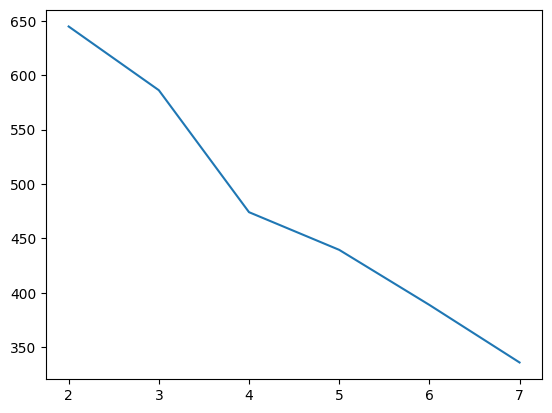

In [35]:
plt.plot(k_values, wcss)

In [36]:
from sklearn.metrics import silhouette_score

In [37]:
k_values = range(2, 8)
score = []

for i in k_values:
  kmeans = KMeans(n_clusters=i, random_state=42)
  kmeans.fit(df_scaled)

  silhoute_avg = silhouette_score(df_scaled, kmeans.labels_)
  score.append(silhoute_avg)

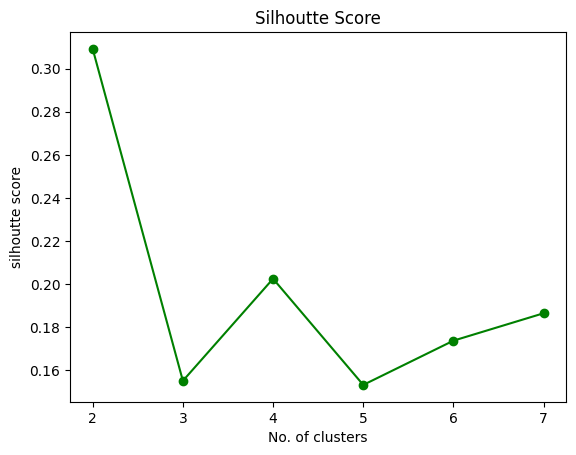

In [38]:
plt.plot(k_values, score, marker='o', color='green')
plt.title("Silhoutte Score")
plt.xlabel("No. of clusters")
plt.ylabel("silhoutte score")
plt.show()

In [39]:
final_model = KMeans(n_clusters=4, random_state=42)

In [40]:
final_model.fit(df_scaled)

KMeans(n_clusters=4, random_state=42)

In [42]:
print(final_model.labels_)

[2 2 2 2 2 2 2 2 2 3 3 3 3 0 3 0 3 3 3 3 3 3 3 3 3 0 3 3 3 0 3 3 3 3 0 3 1
 1 0 1 1 3 0 3 3 3 0 1 1 1 3 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1
 1 1 1 1 3]


In [43]:
data['CluseterId'] = final_model.labels_

In [44]:
data

,Player,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0,Exp,CluseterId
0,SR Tendulkar (INDIA),463,452,41,18426,200,44.83,21367,86.23,49,96,20,23,2
1,KC Sangakkara (Asia/ICC/SL),404,380,41,14234,169,41.98,18048,78.86,25,93,15,15,2
2,RT Ponting (AUS/ICC),375,365,39,13704,164,42.03,17046,80.39,30,82,20,17,2
3,ST Jayasuriya (Asia/SL),445,433,18,13430,189,32.36,14725,91.20,28,68,34,22,2
4,DPMD Jayawardene (Asia/SL),448,418,39,12650,144,33.37,16020,78.96,19,77,28,17,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74,CG Greenidge (WI),128,127,13,5134,133,45.03,7908,64.92,11,31,3,16,1
75,Misbah-ul-Haq (PAK),162,149,31,5122,96,43.40,6945,73.75,0,42,6,13,1
76,PD Collingwood (ENG),197,181,37,5092,120,35.36,6614,76.98,5,26,7,10,1
77,A Symonds (AUS),198,161,33,5088,156,39.75,5504,92.44,6,30,15,11,1


In [45]:
group1 = data[data['CluseterId'] ==1 ]

In [46]:
group1

,Player,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0,Exp,CluseterId
36,NJ Astle (NZ),223,217,14,7090,145,34.92,9760,72.64,16,41,19,12,1
37,GC Smith (Afr/SA),197,194,10,6989,141,37.98,8648,80.81,10,47,8,11,1
39,G Kirsten (SA),185,185,19,6798,188,40.95,9436,72.04,13,45,11,10,1
40,A Flower (ZIM),213,208,16,6786,145,35.34,9097,74.59,4,55,13,11,1
47,RB Richardson (WI),224,217,30,6248,122,33.41,9801,63.74,5,44,8,13,1
48,WU Tharanga (Asia/SL),204,193,14,6140,174,34.30,8183,75.03,14,34,15,12,1
49,ML Hayden (AUS/ICC),161,155,15,6133,181,43.80,7767,78.96,10,36,9,15,1
51,DM Jones (AUS),164,161,25,6068,145,44.61,8362,72.56,7,46,6,10,1
52,DC Boon (AUS),181,177,16,5964,122,37.04,9157,65.13,5,37,6,11,1
53,JN Rhodes (SA),245,220,51,5935,121,35.11,7336,80.90,2,33,12,11,1


In [48]:
import seaborn as sns

Text(0.5, 1.0, 'This plot will show you the clusters based on Runs and Ave')

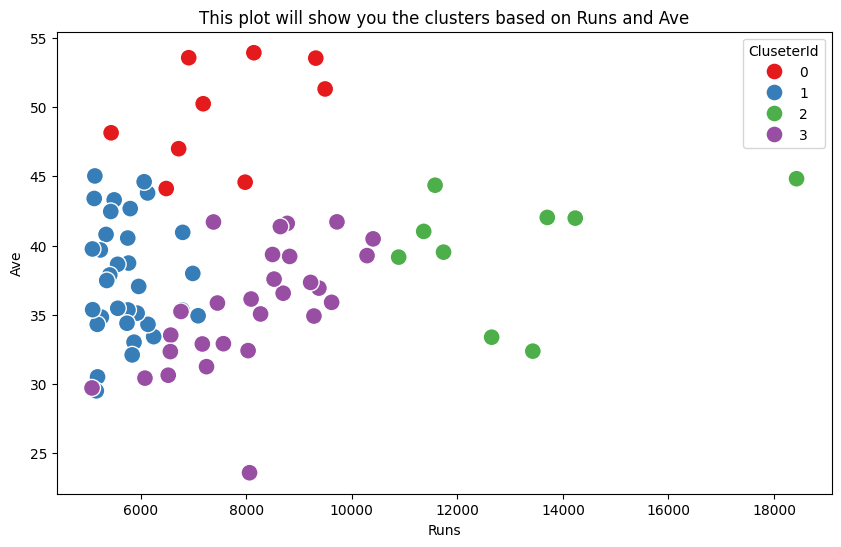

In [54]:
#Plot the clusters created
plt.figure(figsize=(10,6))
sns.scatterplot(data=data,x='Runs',y='Ave',hue='CluseterId',palette='Set1',s=150)
plt.title('This plot will show you the clusters based on Runs and Ave')

In [55]:
#Create a plotly
!pip install plotly

In [56]:
import plotly.express as px

In [59]:
#Create a 3d scatter plot
fig=px.scatter_3d(data,x='Runs',y='Ave',z='SR',color='CluseterId',hover_name='Player',title='3D Scatter Plot of Criceketer Performance')

#Update a layout for better visualisation
fig.update_layout(scene=dict(xaxis_title="Rune",yaxis_title="Average",zaxis_title="Strike Rate"),width=800,height=600)

fig.show()